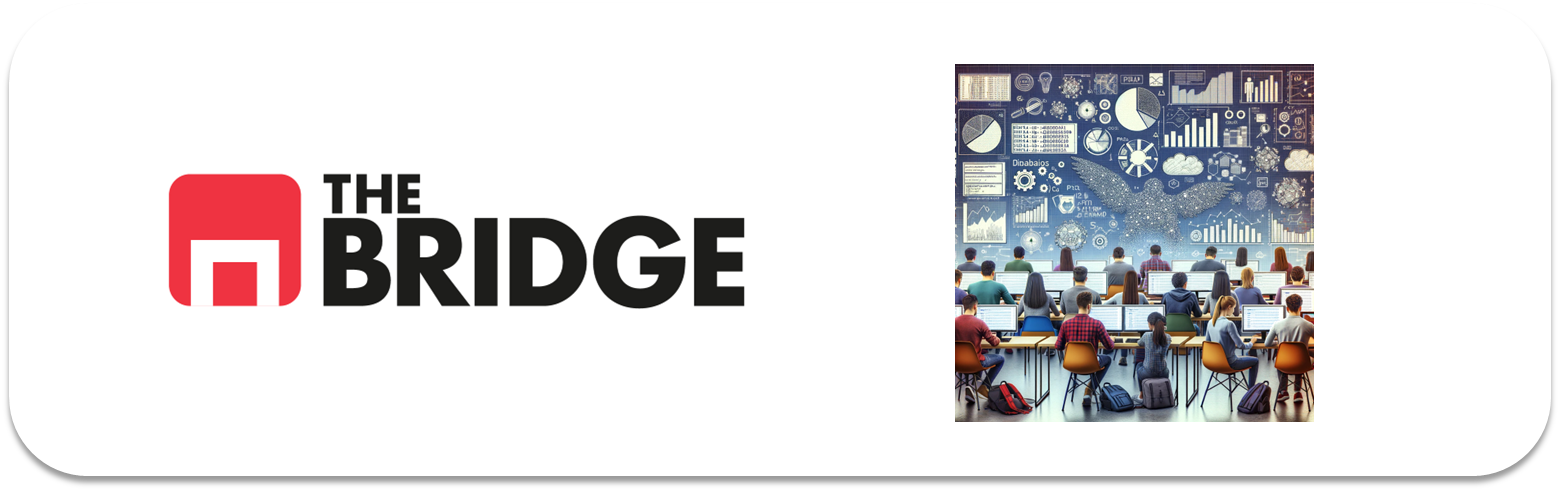

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [1]:
import numpy as np
import pandas as pd
from sklearn import linear_model, metrics, model_selection
from sklearn.linear_model import ElasticNet
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import seaborn as sns

In [2]:
df = pd.read_csv("./data/hard_to_find/obligatoria_hard.csv", sep=r"\s*\|\s*", engine="python")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [4]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


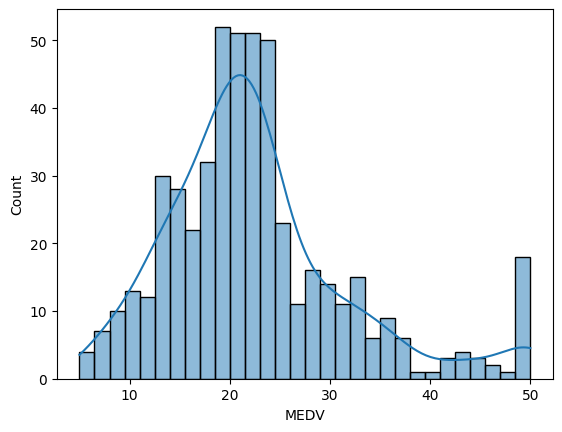

In [5]:
# Analizamos la variable target (Precio mediano de la vivienda), de forma gráfica. como tiene una distribución de forma gaussiana, podemos utilizar el modelo de regresión lineal
target = "MEDV"

sns.histplot(data=df, x=target, bins=30, kde=True);

In [ ]:
# 2 conjuntos
# train_set, test_set = train_test_split(df, test_size = 0.2, random_state = 42)

# Calculamos la correlación para decidir las features
# corr = train_set.corr(numeric_only = True, key = abs) con esta opción para que nos ponga 
# el valor absoluto 
# serie_corr = np.abs(corr[target]).sort_values(ascending=False) podemos hacerle el valor abs por que en 
# realidad nos es indiferente si es negativa o positiva, nos importa la correlación

# antes de definir las features debería de haber mirado la cardinalidad
# los limpites de correlación inferiores a 0.5 los podemos eliminar, no hay un limite específico, lo normal
# sería hacer 3 grupos y quitarnos los débiles.
#
# criterio = 0.33
# features_num = serie_corr[serie_corr > criterio].index.to_list()
# features_num.remove(target)
# features_num.remove("RAD")
#
# colinearidad (establecer un criterio del 0.7/0.3, 0.8/0.2)
# criterio_col = 0.7
# excluidas = []
# corr_numeric = train_set[features_num].corr(numeric_only = True)

for col in features_num:
    print(f"Comprobando colinealidad de {col}")
    if col not in excluidas:
        for col_2, valor_corr in corr_numeric[col].items():
            print(f"\tComprobando {col} con {col_2}")
            if col != col_2 and col_2 in features_num:
                if np.abs(valor_corr) >= criterio_col:
                    print(f"\t\t--> {col} correla con {col_2} al {valor_corr:0.4f}, EXCLUIMOS {col_2} <--")
                    excluidas.append(col_2)
                else:
                    print(f"\t\t{col} correla con {col_2} al {valor_corr:0.4f}, mantenemos {col_2}")
            elif col == col_2:
                print("\t\tSon la misma variable, no comprobamos")
    
    elif col in excluidas:
        print(f"\tLa columna {col} ya ha sido excluida")

excluidas = list(set(excluidas))
print("\nLas variables a excluir son", excluidas)
#
# hacemos un heat map de la colinearidad
#
# features_cat = ["CHAS", "RAD"]
# sns.histplot(x=target, data = train_set[train_set.CHAS == 0], kde = True, color = "red")
# sns.histplot( x = target, data = train_set.CHAS ==1], kde = True);
#
# sns.histplot(x=target, data = train_set[train_set.RAS == 24], kde = True, color = "red")
# sns.histplot(x=target, data = train_set[train_set.RAS != 24], kde = True);



In [ ]:
# features_num
# LSTAT, RM, PTRATIO, INDUS, CRIM, AGE
# train_Set[features_num].hist()
# plt.tight_layout()

# Normalizamos aplicando el log, en líneas generales
#
# sns.histplot(train_set["AGE"] , bins = 20, kde = True, log_scale=10); No tiene sentido,
# no cambia la gráfica, que tipo de normalización le haríamos para hacer una distribución n
# normal, (logaritmica no es)
#
# train_bck = train_set.copy()
#

In [1]:

# antes de aplicar el logaritmo podemos comprobar la asimetria, para saber a que features tenemos que aplicarle el log

print("\n" + "=" * 60)
print("ASIMETRÍA DE FEATURES SELECCIONADAS")
print("=" * 60)

skew = train_back[features_num].skew().sort_values(ascending=False)

for feat, val in skew.items():
    flag = "→ transformar!" if abs(val) > 1 else "→ OK!"
    print(f"{feat:>8}  skew = {val:6.3f}  {flag}")


# aplicamos el log a estas.

features_transform = ["LSTAT", "CRIM"]

for feature in features_transform:
    test_set[feature] = test_set[feature].apply(np.log)

test_set[features_transform].hist()
plt.tight_layout()


# Ahora toca normalizar (minMaxScaler (min=0, max=1), Standard(mean=0, std=1)
# Robusscaler (cuando los outliers son muy grandes)
# StandardScaler (mean=0, std=1)
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()

# entrenamos el modelo para el escalado
#  
# CUIDADO!! TODO LO QUE HACEMOS EN TRAIN LO HACEMOS EN TEST PERO EL TEST NUNCA SE ENTRENA
# SIMPLEMENTE SE APLICA LO QUE HACEMOS EN TRAIN
# 
# SE ENTRENA Y SE TRANSFORMA EN TRAIN, Y SE TRANSFORMA SOLAMENTE EN TEST

# train_set[features_num] = scaler.fit_transform(train_set[features_num])

# test_set[features_num] = scaler.transform(test_set[features_num])



ASIMETRÍA DE FEATURES SELECCIONADAS


NameError: name 'df' is not defined

In [ ]:
train_set.info()
train_set[features_num].describe()

test_set.info()
test_set[features_num].describe()

NameError: name 'train_set' is not defined

In [ ]:
features_all = features_num + features_cat
features_all
# LSTAT, RM, PTRATIO, INDUS, CRIM, AGE, CHAS, RAD

#Dividimos nuestro x_train, y_train, x_set, y_set
X_train = train_set[features_all]
y_train = train_set[target]

X_test = test_set[features_all]
y_test = test_set[target]

from sklearn.linerar_moedl import LinearRegression

lin_reg = LinearRegression()

# Entrenemos nuestro train
lin_reg.fit(X_train, y_train)



# lin_reg.intercept_ 
# donde cruza (donde x es 0)

# lin_reg.coef_ (el peso que tiene cada feature en el modelo) 
# El multiplicador

# lin_reg.features_names_in_
# nombre de las features

# EVALUAMOS COMO HA IDO NUESTRO MODELO
# Hacemos ahora las predicciones

from sklearn.metrics import median_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

pred_train = lin_reg.predict(X_train)

print("MAE:", median_absolute_error(y_train, pred_train))
print("RMSE:", root_mean_squared_error(y_train, pred_train))
print("MAPE:", mean_absolute_percentage_error(y_train, pred_train))
print("R^2:", lin_reg.score(X_train, y_train))

# R2 - RANGO DE 0-1 - tenemos uno ahora de 0.75
# MAPE - RANGO DE 0-100 - 17.19 (tenemos un error del 17%)
# RMSE - 4.62 - 
# MAE - 2.78 - 



pred_test = lin_reg.predict(X_test)

print("MAE:", median_absolute_error(y_test, pred_test))
print("RMSE:", root_mean_squared_error(y_test, pred_test))
print("MAPE:", mean_absolute_percentage_error(y_train, pred_test))
print("R^2:", lin_reg.score(X_test y_test))

# R2 - RANGO DE 0-1 - tenemos uno ahora de 0.72
# MAPE - RANGO DE 0-100 - 14.32
# RMSE - 4.50 - 
# MAE - 1.71 - 


# comprobamos los resultados de train frente a test y evaluamos como es nuestro modelo

# visualizamos uno frente a otro
sns.scatterplot(x=y_test, y=pred_test)
plt.plot([0.55], [0.55], "red")
plt.grid()
plt.xlabel("Prices")
plt.ylabel("Prediction")

In [ ]:
# Regularizamos con Ridge, Lasso, ElasticNet

# Train baja y el test sube (MSE) cambiando el alpha

from sklearn.linear_from sklearn.linear_model import Ridge, Lasso, ElasticNet

ridge_reg = Ridge(alpha = 1) 
lasso_reg = Lasso(alpha = 1) 
elastic_reg = ElasticNet(alpha = 1, l1_ratio = 0.5)

for nombre, model in zip(["Ridge","Lasso","ElasticNet"],[ridge_reg, lasso_reg, elastic_reg]):
    model.fit(X_train, y_train)
    print("Modelo:", nombre)
    print("TRAIN:")
    pred_train  = model.predict(X_train)
    print("\tMAE:", median_absolute_error(y_train, pred_train))
    print("\tRMSE:", root_mean_squared_error(y_train, pred_train))
    print("MAPE:", mean_absolute_percentage_error(y_train, pred_train) * 100)
    print("\tR^2:", model.score(X_train, y_train))
    print("TEST:")
    pred_test = model.predict(X_test)
    print("\tMAE:", median_absolute_error(y_test, pred_test))
    print("\tRMSE:", root_mean_squared_error(y_test, pred_test))
    print("MAPE:", mean_absolute_percentage_error(y_test, pred_test) * 100)
    print("\tR^2:", model.score(X_test, y_test))
    print("")


In [6]:
# Creamos un split del dataset en train y test al 80/20 empleando sklearn.

from sklearn.model_selection import train_test_split

# Definimos X e y
X = df.drop(columns=["MEDV"])
y = df["MEDV"]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Comprobamos dimensiones
print("X:", X.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X: (506, 12)
X_train: (404, 12)
X_test: (102, 12)
y_train: (404,)
y_test: (102,)


5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.

In [7]:
# Seleccionamos las features, para ello comenzamos estudiando la correlación que tienen con la variable TARGET
corr = df.corr(numeric_only=True)["MEDV"].sort_values(ascending=False)
corr


MEDV       1.000000
RM         0.695360
ZN         0.360445
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

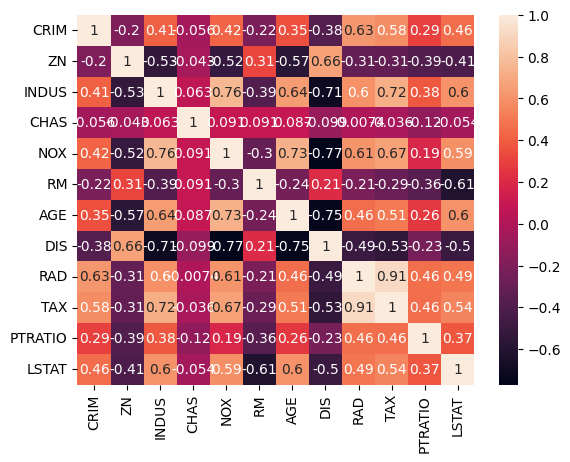

In [8]:
# Comprobamos la correlación de forma gráfica con un mapa de calor
sns.heatmap(X.corr(numeric_only = True),annot=True);
plt.show();

Selección de Features

- Correlación entre |1 – 0.5| → correlación fuerte
  - RM — nº habitaciones promedio
  - LSTAT — estatus socioeconómico bajo
  - PTRATIO — ratio alumnos profesor

- Correlación entre |0.5 – 0.3| → correlación moderada
  - INDUS — zona industrial proporción
  - TAX — impuesto propiedad anual
  - NOX — contaminación óxidos nitrógeno
  - CRIM — tasa criminalidad zona
  - RAD — acceso autopistas índice
  - AGE — viviendas antiguas proporción

- Correlación entre |0.3 – 0.2| → correlación débil
  - ZN — zona residencial baja
  - DIS — distancia centros empleo

- Correlación < 0.2 → descartadas
  - CHAS — cerca río Charles


In [9]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'LSTAT', 'MEDV'],
      dtype='str')

In [10]:
# Como todas las variables son numéricas, creamos una lista de todas las variables, quitando CHAS que es la que hemos descartado por que 
# su correlación es muy baja y quitamos la variable Target
features_num = df.columns.drop(["CHAS", "MEDV"]).tolist()
features_num


['CRIM',
 'ZN',
 'INDUS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'LSTAT']

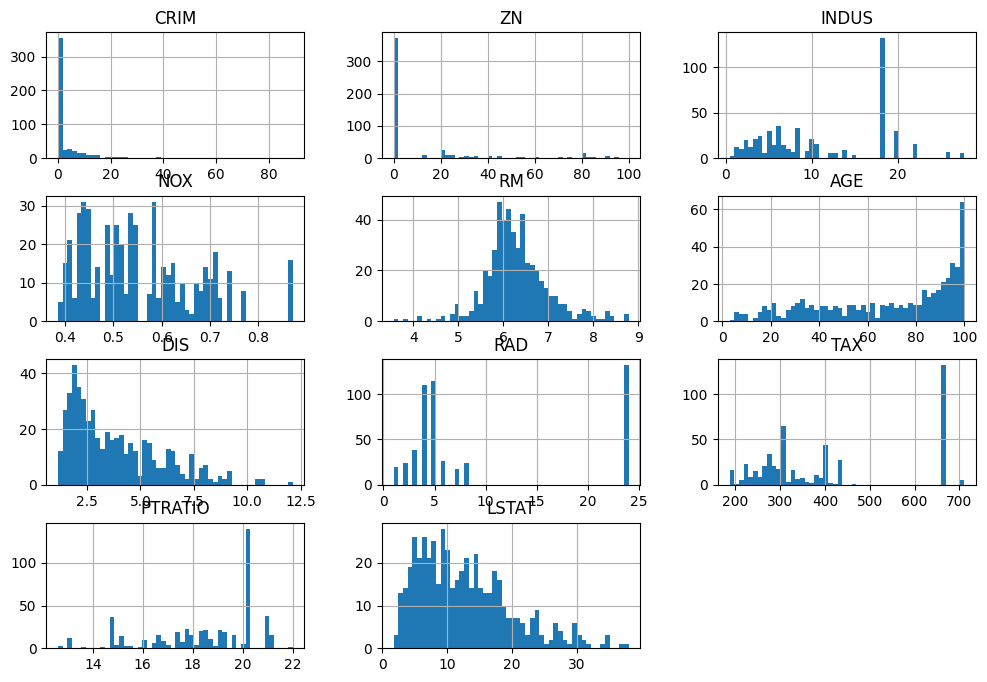

In [11]:
# Creamos un histogramas para ver todas las variables numéricas seleccionadas (features_num) del dataset
df[features_num].hist(bins=50, figsize=(12, 8))
plt.show()


In [12]:
from sklearn.preprocessing import StandardScaler
 
#. Seleccionamos las columnas a las que aplicar el log

cols_log = ["CRIM", "ZN", "INDUS", "RAD", "TAX", "LSTAT", "PTRATIO"] 

for col in cols_log:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

In [13]:
# Aplicamos StandardScaler a todas nuestras features

scaler = StandardScaler()

X_train[features_num] = scaler.fit_transform(X_train[features_num])
X_test[features_num] = scaler.transform(X_test[features_num])


In [14]:
# Comprobación de que el escalado se ha realizado correctamente, std = 1, mean = 0.
X_train.describe()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT
count,4.040000e+02,4.040000e+02,4.040000e+02,404.000000,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02,4.040000e+02
mean,-1.099231e-17,-1.066254e-16,7.914461e-17,0.071782,-5.111423e-16,-2.616169e-16,-4.858600e-16,5.248827e-17,5.342261e-16,-1.138803e-15,-3.826972e-15,-1.011292e-16
std,1.001240e+00,1.001240e+00,1.001240e+00,0.258447,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00,1.001240e+00
min,-7.874414e-01,-6.011685e-01,-2.594623e+00,0.000000,-1.458711e+00,-3.461733e+00,-2.348206e+00,-1.258391e+00,-1.803452e+00,-1.759682e+00,-2.827498e+00,-2.699511e+00
25%,-7.192423e-01,-6.011685e-01,-7.071398e-01,0.000000,-8.887828e-01,-6.003488e-01,-8.228264e-01,-8.081981e-01,-5.752455e-01,-7.419154e-01,-6.144868e-01,-7.591761e-01
50%,-5.677040e-01,-6.011685e-01,-4.107306e-02,0.000000,-1.572334e-01,-1.494427e-01,3.270201e-01,-2.971196e-01,-3.308597e-01,-3.143952e-01,2.194785e-01,3.462001e-02
75%,6.171079e-01,1.263538e+00,9.962637e-01,0.000000,6.338607e-01,4.528240e-01,8.974727e-01,7.481981e-01,5.549886e-01,1.475801e+00,8.228938e-01,7.323842e-01
max,3.633550e+00,2.225496e+00,1.608685e+00,1.000000,2.675394e+00,3.477564e+00,1.124581e+00,3.907900e+00,1.582063e+00,1.642609e+00,1.493001e+00,2.230640e+00


7. Construye un modelo de regresión lineal.


In [15]:
# Modelo de regresión lineal
lr = linear_model.LinearRegression()

#Entrenamos el modelo
lr.fit(X_train, y_train)

# Predicciones
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

# Métricas
print("---TRAIN---")
print("Train MSE:", metrics.mean_squared_error(y_train, y_pred_train))
print("Train RMSE:", np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
print("Train R2:", metrics.r2_score(y_train, y_pred_train))
print("---TEST---")
print("Test MSE:", metrics.mean_squared_error(y_test, y_pred_test))
print("Test RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))
print("Test R2:", metrics.r2_score(y_test, y_pred_test))

---TRAIN---
Train MSE: 18.499738100416526
Train RMSE: 4.301132188205394
Train R2: 0.7870494618124058
---TEST---
Test MSE: 18.3204125156886
Test RMSE: 4.280235100515928
Test R2: 0.7501777253788156


8. Analiza si lo crees conveniente los pesos y la importancia de las features.


In [16]:
# Eliminamos del train y del test la variable que hemos descartado por su baja correlación con el Target
X_train = X_train.drop(columns=["CHAS"])
X_test = X_test.drop(columns=["CHAS"])

# Reentrenamos el modelo sin estas dos columnas
lr.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
feat_coef = pd.DataFrame(
    lr.coef_,
    index=X_train.columns,
    columns=['importance_standarized']
).sort_values('importance_standarized', ascending=False)

feat_coef

,importance_standarized
RAD,2.028610
RM,1.910865
AGE,0.559616
ZN,0.324640
INDUS,-0.320874
TAX,-1.279816
NOX,-1.318537
CRIM,-1.381075
PTRATIO,-1.790286
DIS,-2.810539


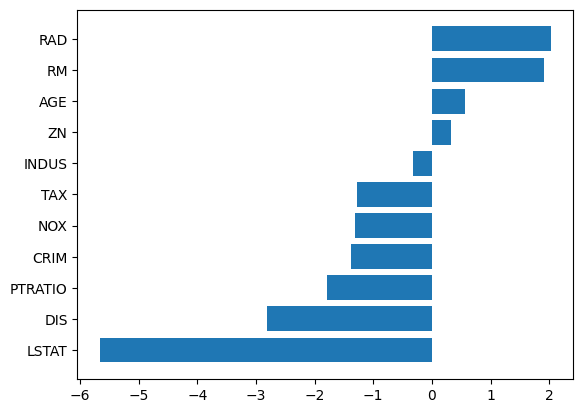

In [18]:
features = feat_coef.sort_values('importance_standarized')
plt.barh(features.index,features.importance_standarized)
plt.show()

10. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.

In [19]:
# Comprobamos los valores del X_train (media y std), para ver si están bien escalados
X_train.mean(), X_train.std()


(CRIM      -1.099231e-17
 ZN        -1.066254e-16
 INDUS      7.914461e-17
 NOX       -5.111423e-16
 RM        -2.616169e-16
 AGE       -4.858600e-16
 DIS        5.248827e-17
 RAD        5.342261e-16
 TAX       -1.138803e-15
 PTRATIO   -3.826972e-15
 LSTAT     -1.011292e-16
 dtype: float64,
 CRIM       1.00124
 ZN         1.00124
 INDUS      1.00124
 NOX        1.00124
 RM         1.00124
 AGE        1.00124
 DIS        1.00124
 RAD        1.00124
 TAX        1.00124
 PTRATIO    1.00124
 LSTAT      1.00124
 dtype: float64)

In [34]:
from sklearn.linear_model import Ridge

ridgeR = Ridge(alpha = 10)  # alpha es lambda 
ridgeR.fit(X_train, y_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(y_train, lr.predict(X_train)), 2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(y_test, lr.predict(X_test)), 2))
print("Test RMSE sin regularización:", round(np.sqrt(metrics.mean_squared_error(y_test, lr.predict(X_test))), 2))

print("---RIDGE para alpha = 10---")
print("Train MSE Ridge:", round(metrics.mean_squared_error(y_train, ridgeR.predict(X_train)), 2))
print("Test MSE Ridge:", round(metrics.mean_squared_error(y_test, ridgeR.predict(X_test)), 2))
print("Test RMSE Ridge:", round(np.sqrt(metrics.mean_squared_error(y_test, ridgeR.predict(X_test))), 2))


Train MSE sin regularización: 18.94
Test MSE sin regularización: 18.56
Test RMSE sin regularización: 4.31
---RIDGE para alpha = 10---
Train MSE Ridge: 19.02
Test MSE Ridge: 18.71
Test RMSE Ridge: 4.33


In [33]:
ridgeR = Ridge(alpha = 1)  # alpha es lambda 
ridgeR.fit(X_train, y_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(y_train, lr.predict(X_train)), 2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(y_test, lr.predict(X_test)), 2))
print("Test RMSE sin regularización:", round(np.sqrt(metrics.mean_squared_error(y_test, lr.predict(X_test))), 2))

print("---RIDGE para alpha = 1---")
print("Train MSE Ridge:", round(metrics.mean_squared_error(y_train, ridgeR.predict(X_train)), 2))
print("Test MSE Ridge:", round(metrics.mean_squared_error(y_test, ridgeR.predict(X_test)), 2))
print("Test RMSE Ridge:", round(np.sqrt(metrics.mean_squared_error(y_test, ridgeR.predict(X_test))), 2))


Train MSE sin regularización: 18.94
Test MSE sin regularización: 18.56
Test RMSE sin regularización: 4.31
---RIDGE para alpha = 1---
Train MSE Ridge: 18.94
Test MSE Ridge: 18.57
Test RMSE Ridge: 4.31


In [32]:
ridgeR = Ridge(5)  # alpha es lambda 
ridgeR.fit(X_train, y_train)

print("Train MSE sin regularización:", round(metrics.mean_squared_error(y_train, lr.predict(X_train)), 2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(y_test, lr.predict(X_test)), 2))
print("Test RMSE sin regularización:", round(np.sqrt(metrics.mean_squared_error(y_test, lr.predict(X_test))), 2))


print("---RIDGE para alpha = 5---")
print("Train MSE Ridge:", round(metrics.mean_squared_error(y_train, ridgeR.predict(X_train)), 2))
print("Test MSE Ridge:", round(metrics.mean_squared_error(y_test, ridgeR.predict(X_test)), 2))
print("Test RMSE Ridge:", round(np.sqrt(metrics.mean_squared_error(y_test, ridgeR.predict(X_test))), 2))

Train MSE sin regularización: 18.94
Test MSE sin regularización: 18.56
Test RMSE sin regularización: 4.31
---RIDGE para alpha = 5---
Train MSE Ridge: 18.96
Test MSE Ridge: 18.62
Test RMSE Ridge: 4.32


In [29]:
from sklearn.linear_model import Lasso

lassoR = Lasso(alpha = 0.1) 
lassoR.fit(X_train, y_train) 

print("Train MSE sin regularización:", round(metrics.mean_squared_error(y_train, lr.predict(X_train)), 2))
print("Test MSE sin regularización:", round(metrics.mean_squared_error(y_test, lr.predict(X_test)), 2))
print("Test RMSE sin regularización:", round(np.sqrt(metrics.mean_squared_error(y_test, lr.predict(X_test))), 2))


print("---LASSO para alpha = 0.1---")
print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, lassoR.predict(X_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, lassoR.predict(X_test)))

Train MSE sin regularización: 18.94
Test MSE sin regularización: 18.56
Test RMSE sin regularización: 4.31
---LASSO para alpha = 0.1---
Train MSE: 19.3254
Test MSE: 19.3541


In [24]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha = 0.5, l1_ratio = 0.5)
elastic_net.fit(X_train, y_train)

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, elastic_net.predict(X_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, elastic_net.predict(X_test)))

Train MSE: 23.0365
Test MSE: 21.8731


11. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?


Tras comparar los tres modelos de regularización (Ridge, Lasso y Elastic Net) con el modelo lineal sin regularización, observo que ninguno de los modelos regularizados mejora el rendimiento en test. Ridge apenas modifica los resultados, Lasso empeora ligeramente y Elastic Net empeora de forma notable. Dado que el modelo lineal simple obtiene el menor error en test me quedo con el modelo lineal sin regularización por ser el que mejor generaliza en este caso.